# Resolución de ecuaciones diferenciales por metodo de diferencias finitas

Recopilando las ecuaciones con valores promedio y una sola pieza (tamaño de 1 probeta):
$$\frac{\partial{T_r}}{\partial{t}}=0.0054\cdot P(t)-1.94\times 10^{-11}\cdot (T_{r}^4-T_{1}^4)$$
$$\frac{dT_p}{dt}=2.68\times10^{-12}(T_1^4-T_p^4)$$
$$\frac{dT_t}{dt}=2.0679\times 10^{-11}(T_1^4-T_t^4)$$
$$\frac{\partial T_{1}}{\partial t}=1.95\times 10^{-12}(T_r^4-T_1^4)-7.77\times 10^{-4}(T_1-T_2)-6.85\times10^{-16}(T_1^4-T_t^4)-7.80\times10^{-14}(T_1^4-T_p^4)$$
$$\frac{\partial{T_2}}{\partial{t}}=5.22\times 10^{-4}(T_1-T_2)-9.63\times 10^{-4}(T_2-T_3)$$
$$\frac{\partial{T_3}}{\partial{t}}=0.0021(T_2-T_3)-0.0014(T_3-T_4)$$
$$\frac{\partial{T_4}}{\partial{t}}=0.0023(T_3-T_4)-0.0031(T_4-T_5)$$
$$\frac{\partial{T_5}}{\partial{t}}=0.0054(T_4-T_5)-0.0202(T_5-T_{\infty})-1.98\times10^{-11}(T_5^4-T_{\infty}^4)$$

Recopilando las ecuaciones con propiedades que varian con la temperatura y con variaciones de carga:
$$\frac{\partial{T_r}}{\partial{t}}=\frac{3.44}{c_r(T)}\cdot P(t)-\frac{1.24\times 10^{-8}}{c_r(T)}\cdot (T_{r}^4-T_{1}^4)$$
$$c_r(T)=-0.0002T^2 + 0.4804T + 467.6354\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$$
$$\frac{dT_p}{dt}=\left(7.99\times10^{-13}+6.57\times10^{-13}\cdot\sqrt{\frac{1}{m_p}}\right)\cdot(T_1^4-T_p^4)$$
$$\frac{dT_t}{dt}=2.0679\times 10^{-11}(T_1^4-T_t^4)$$
$$\frac{\partial T_{1}}{\partial t}=1.95\times 10^{-12}(T_r^4-T_1^4)-0.0039\cdot k_{lra}(T)(T_1-T_2)-6.85\times10^{-16}(T_1^4-T_t^4)-\left(1.95\times10^{-13}\cdot m_p+1.59\times10^{-13}\cdot \sqrt{m_p}\right) \cdot(T_1^4-T_p^4)$$
$$k_{lra}(T)=0.0002T+0.0990$$
$$\frac{\partial{T_2}}{\partial{t}}=0.0026\cdot k_{lra}(T)(T_1-T_2)-0.0051\cdot k_{fc}(T)(T_2-T_3)$$
$$k_{fc}(T)=0.0002T+0.0160$$
$$\frac{\partial{T_3}}{\partial{t}}=0.0113\cdot k_{cf}(T)(T_2-T_3)-0.0161\cdot k_{lr}(T)(T_3-T_4)$$
$$k_{lr}(T)=0.0001T+0.0301$$
$$\frac{\partial{T_4}}{\partial{t}}=0.0253\cdot k_{lr}(T)(T_3-T_4)-0.0342\cdot k_{lr}(T)(T_4-T_5)$$
$$\frac{\partial{T_5}}{\partial{t}}=0.0595\cdot k_{lr}(T)(T_4-T_5)-0.0202(T_5-T_{\infty})-1.98\times10^{-11}(T_5^4-T_{\infty}^4)$$

# Y con cargas variables para le nodo 1 y para la pieza, 

## Método explicito en diferencias finitas

Para resolver las ecuaciones, utilizamos diferencias finitas con el método explicito:
$$\frac{\partial{T}}{\partial t}=\frac{T_{i+1}-T_{i}}{\Delta t}$$

Reemplazando en todas las ecuaciones, tenemos
$$T_{r(i+1)}=T_{r(i)}+\frac{\partial{T_r}}{\partial{t}}\Delta t$$
$$T_{p(i+1)}=T_{p(i)}+\frac{\partial{T_p}}{\partial{t}}\Delta t$$
$$T_{t(i+1)}=T_{t(i)}+\frac{\partial{T_t}}{\partial{t}}\Delta t$$
$$T_{1(i+1)}=T_{1(i)}+\frac{\partial{T_1}}{\partial{t}}\Delta t$$
$$T_{2(i+1)}=T_{2(i)}+\frac{\partial{T_2}}{\partial{t}}\Delta t$$
$$T_{3(i+1)}=T_{3(i)}+\frac{\partial{T_3}}{\partial{t}}\Delta t$$
$$T_{4(i+1)}=T_{4(i)}+\frac{\partial{T_4}}{\partial{t}}\Delta t$$
$$T_{5(i+1)}=T_{5(i)}+\frac{\partial{T_5}}{\partial{t}}\Delta t$$

Para determinar el $\Delta t$ máximo utilizamos el criterio de estabilidad de Fourier, requerido la resolución por diferencias finitas, en el método explicito tomamos la ecuación mas restrictiva:
Como trabajaremos con las ecuaciónes con parámetros dependientes de la temperatura, tomamos las ecuacuiones con mas restricciones, las cuales pueden presentar cambios mas rapidos, estos son las ecuaciones con terminos de radiación al interior del horno.

### Para la resistencia, la ecuación original:
$$\frac{\partial{T_r}}{\partial{t}}=\frac{1}{\rho_r\cdot V_r\cdot c_r}\cdot P(t)-\frac{\varepsilon_{r}\cdot\sigma\cdot A_r}{\rho_r\cdot V_r\cdot c_r}\cdot (T_{r}^4-T_{1}^4)$$
$$c_r(T)=-0.0002T^2 + 0.4804T + 467.6354\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$$

Usando el coeficiente de radiación $h_{rad}$ podemos linealizar la ecuación:
$$\frac{\partial{T_r}}{\partial{t}}=\frac{1}{\rho_r\cdot V_r\cdot c_r}\cdot P(t)-\frac{h_{r(rad)}\cdot A_r}{\rho_r\cdot V_r\cdot c_r}\cdot (T_{r}-T_{1})$$
$$h_{r(rad)}=\varepsilon_{r}\cdot\sigma(T_{r}^2+T_{1}^2)(T_r+T_1)$$

Considerando las condiciones mas críticas, cuando $T_1$ es igual a $1000\text{ °C}=1273.15\text{ K}$ y la resistencia $T_r$ esta unos $100\text{ K}$ mas elevado $T_r=1373.15\text{ K}$:

$\varepsilon_r=0.7$, Emisividad del alambre (Hoja de datos de Kantal A1).\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.

$$h_{r(rad)}=368.3\text{ W m}^{-2}\text{ K}^{-1}$$
$$c_r(T)=754\text{ J kg}^{-1}\text{ K}^{-1}$$

Entonces:\
$\rho_r=7100\text{ kg}\text{ cm}^{-3}$, Densidad del alambre (Hoja de datos de Kantal A1).\
$V_r=4.1\times 10^{-5}\text{ m}^3$, Volumen del alamabre (Calculado en el documento del proyecto).\
$A_r=0.091 \text{ m}^2$, Es el area del alambrea (Calculado en el documento del proyecto).

$$\frac{\partial{T_r}}{\partial{t}}=0.0046\cdot P(t)-0.1527(T_{r}-T_{1})$$
$$\frac{T_{r(i+1)}-T_{r(i)}}{\Delta t}=0.0046\cdot P(t)-0.1527\cdot T_r+0.1520\cdot T_1$$
$$T_{r(i+1)}=T_{r(i)} + \Delta t(0.0046\cdot P(t)-0.1527\cdot T_r+0.1520\cdot T_1)$$
$$T_{r(i+1)}=T_{r(i)}(1 -0.1527\cdot\Delta t) + 0.0046\cdot P(t)\Delta t +0.1520\cdot T_1\Delta t$$
De la utlima ecuación:
$$1 -0.1527\cdot\Delta t\geq 0$$
$$\Delta t\leq\frac{1}{0.1527}=6.55\text{ s}$$

### Para la pieza, acero A36 (Una probeta), la ecuación original:
$$\frac{dT_p}{dt}=\frac{\varepsilon_p\cdot\sigma\cdot A_p}{\rho_p\cdot V_p\cdot c_p}\cdot(T_1^4-T_p^4)$$
Usando el coeficiente de radiación $h_{rad}$ podemos linealizar la ecuación:
$$\frac{dT_p}{dt}=\frac{h_{p(rad)}\cdot A_p}{\rho_p\cdot V_p\cdot c_p}\cdot(T_1-T_p)$$
$$h_{p(rad)}=\varepsilon_{p}\cdot\sigma\cdot(T_1^2+T_p^2)(T_1+T_p)$$
Considerando las condiciones mas críticas, cuando $T_p$  y $T_1$ son iguales a $1000\text{ °C}=1273.15\text{ K}$.

$\varepsilon_p=0.75$, Segun Cengel(2017) para acero al carbono.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.

$$h_{p(rad)}=351.0\text{ W m}^{-2}\text{ K}^{-1}$$

Entonces:\
$A_p=0.0034\text{ m}^2$, Area superficial de la pieza.\
$\rho_p=7833\text{ kg m}^{-3}$, Densidad del acero. (Cengel, 2012).\
$V_p=1.52\times10^{-5}\text{ m}^3$, Volumen de la pieza.\
$c_p=453\text{ J kg}^{-1}\text{ K}^{-1}$, Calor especifico del acero. (Cengel, 2012)

$$\frac{dT_p}{dt}=0.0221(T_1-T_p)$$
$$\frac{T_{p(i+1)}-T_{p(i)}}{\Delta t}=0.0221\cdot T_1-0.0221\cdot T_p$$
$$T_{p(i+1)}=T_{p(i)} + \Delta t(0.0221\cdot T_1-0.0221\cdot T_p)$$
$$T_{p(i+1)}=T_{p(i)}(1 -0.0221\cdot\Delta t) + 0.0221\cdot T_1\Delta t$$
De la utlima ecuación:
$$1 -0.0221\cdot\Delta t\geq 0$$
$$\Delta t\leq\frac{1}{0.0221}=45.2\text{ s}$$

### Para la termocupla tipo K:
$$\frac{dT_t}{dt}=\frac{\varepsilon_p\cdot\sigma\cdot A_t}{\rho_t\cdot V_t\cdot c_t}\cdot(T_1^4-T_t^4)$$
Usando el coeficiente de radiación $h_{rad}$ podemos linealizar la ecuación:
$$\frac{dT_t}{dt}=\frac{h_{t(rad)}\cdot A_t}{\rho_t\cdot V_t\cdot c_t}\cdot(T_1-T_t)$$
$$h_{t(rad)}=\varepsilon_{t}\cdot\sigma\cdot(T_1^2+T_t^2)(T_1+T_t)$$
Considerando las condiciones mas críticas, cuando $T_t$  y $T_1$ son iguales a $1000\text{ °C}=1273.15\text{ K}$.

$\varepsilon_t=0.80$, Segun Incropera(2017) para superficies metalicas oxidadas.\
$\sigma= 5.67 \times 10^{-8} \text{ W m}^{-2} \text{ K}^{-4}$, Constante de Stefan-Boltzmann.

$$h_{t(rad)}=374.4\text{ W m}^{-2}\text{ K}^{-1}$$

Entonces:\
$A_t=2.8\times 10^{-5}\text{ m}^2$, Area de la termocupla.\
$\rho_t=8555\text{ kg}\text{ m}^{-3}$, Densidad promedio entre Chromel y Alumel.\
$V_t=1.4\times 10^{-8}\text{ m}$, Volumen de la termocupla.\
$c_t=512.8\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Valor promedio de calor especifico entre Alumel y Chromel.

$$\frac{dT_t}{dt}=0.1707(T_1-T_t)$$
$$\frac{T_{t(i+1)}-T_{t(i)}}{\Delta t}=0.1707\cdot T_1-0.1707\cdot T_t$$
$$T_{t(i+1)}=T_{t(i)} + \Delta t(0.1707\cdot T_1-0.1707\cdot T_t)$$
$$T_{t(i+1)}=T_{t(i)}(1 -0.1707\cdot\Delta t) + 0.1707\cdot T_1\Delta t$$
De la utlima ecuación:
$$1 -0.1707\cdot\Delta t\geq 0$$
$$\Delta t\leq\frac{1}{0.1707}=5.85\text{ s}$$

### Para el Nodo 1 (Cara interior Ladrilo refractario aislante)
$$\frac{\partial T_{1}}{\partial t}=\frac{2\cdot\varepsilon_r\cdot\sigma\cdot A_r}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_r^4-T_1^4)-\frac{2\cdot k_{lra}}{\rho_{lra}\cdot c_{lra}\cdot\Delta x_{lra}^2}(T_1-T_2)-\frac{2\cdot\varepsilon_t\cdot\sigma\cdot A_t}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1^4-T_t^4)-\frac{2\cdot\varepsilon_p\cdot\sigma\cdot A_p}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1^4-T_p^4)$$
Usando el coeficiente de radiación $h_{rad}$ podemos linealizar la ecuación:
$$\frac{\partial T_{1}}{\partial t}=\frac{2\cdot h_{r(rad)}\cdot A_r}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_r-T_1)-\frac{2\cdot k_{lra}}{\rho_{lra}\cdot c_{lra}\cdot\Delta x_{lra}^2}(T_1-T_2)-\frac{2\cdot h_{t(rad)}\cdot A_t}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1-T_t)-\frac{2\cdot h_{p(rad)}\cdot A_p}{\rho_{lra}\cdot A_{lra(prom)}\cdot c_{lra}\cdot\Delta x_{lra}}(T_1-T_p)$$
$$k_{lra}(T)=0.0002T+0.0990 \text{ W m}^{-1}\text{ K}^{-1}$$

Donde $h_{r(rad)}$, $h_{p(rad)}$ y $h_{t(rad)}$ ya fueron calculados antes, en condiciones específicas, y la conductividad del material aislante es asumido a $1000\text{ °C}=1273.15\text{ K}$.
$$h_{r(rad)}=368.3\text{ W m}^{-2}\text{ K}^{-1}$$
$$h_{p(rad)}=351.0\text{ W m}^{-2}\text{ K}^{-1}$$
$$h_{t(rad)}=374.4\text{ W m}^{-2}\text{ K}^{-1}$$
Y la conductividad 
$$k_{lra}(T)=0.31 \text{ W m}^{-1}\text{ K}^{-1}$$
Entonces:\
$A_r=0.091 \text{ m}^2$, Es el area del alambrea (Calculado en el documento del proyecto).\
$A_t=2.8\times 10^{-5}\text{ m}^2$, Area de la termocupla.\
$A_p=0.0034\text{ m}^2$, Area superficial de la pieza.\
$A_{lra(prom)}=0.18\text{ m}^2$, Area promedio del material dentro el nodo examinado.\
$\rho_{lra}=770\text{ kg}\text{ m}^{-3}$, Densidad del ladrillo refractario aislante.\
$c_{lra}=1070\text{ J}\text{ kg}^{-1}\text{ K}^{-1}$, Calor específico del ladrillo refractario aislante.\
$\Delta x_{lra}=0.025\text{ m}$, Espesor del ladrillo refractario aislante.\

$$\frac{\partial T_{1}}{\partial t}=0.0181(T_r-T_1)-0.0012(T_1-T_2)-5.66\times10^{-6}(T_1-T_t)-6.44\times10^{-4}(T_1-T_p)$$
$$\frac{T_{1(i+1)}-T_{1(i)}}{\Delta t}=0.0181(T_r-T_1)-0.0012(T_1-T_2)-5.66\times10^{-6}(T_1-T_t)-6.44\times10^{-4}(T_1-T_p)$$
$$T_{1(i+1)}=T_{1(i)} + \Delta t(0.0181\cdot T_r-0.0181\cdot T_1 - 0.0012\cdot T_1+0.0012\cdot T_2 - 5.66\times10^{-6}\cdot T_1+5.66\times10^{-6}\cdot T_t - 6.44\times10^{-4}\cdot T_1+6.44\times10^{-4}\cdot T_p)$$
$$T_{1(i+1)}=T_{1(i)}(1 - 0.0181\cdot\Delta t - 0.0012\cdot\Delta t - 5.66\times10^{-6}\cdot\Delta t - 6.44\times10^{-4}\cdot\Delta t)+\Delta t(0.0181\cdot T_r+0.0012\cdot T_2+5.66\times10^{-6}\cdot T_t+6.44\times10^{-4}\cdot T_p)$$
De la utlima ecuación:
$$1 - 0.0181\cdot\Delta t - 0.0012\cdot\Delta t - 5.66\times10^{-6}\cdot\Delta t - 6.44\times10^{-4}\cdot\Delta t\geq 0$$
$$\Delta t\leq\frac{1}{0.0181 + 0.0012 + 5.66\times10^{-6} + 6.44\times10^{-4}}=50.12\text{ s}$$

El tiempo mas restrictivo es el de la termocupla con un máximo de tiempo de $\Delta t=5.85\text{ s}$. Cualquier $\Delta t$ menor a esta cantidad para la simulación y resolución mantendrá el sistema estable. De igual manera con el tiempo de muestreo para el sistema de control. 

Iniciando simulación térmica. Por favor, espera...
¡Simulación completada con éxito!


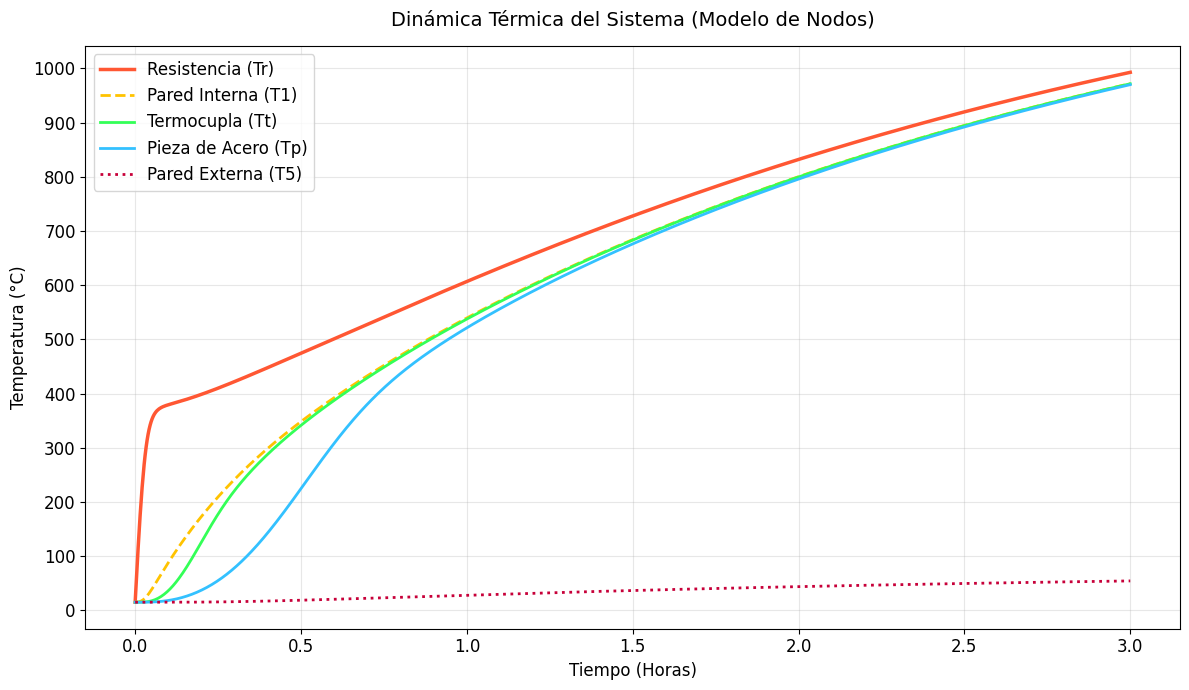

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. Parámetros y Condiciones Iniciales
# ==========================================
T_inf_C = 15.0              # Temperatura ambiente en Celsius
T_inf = T_inf_C + 273.15    # Temperatura ambiente en Kelvin
P_nominal = 600.0          # Potencia eléctrica de la resistencia en Watts (P(t))
m_p = 0.120                # Masa de una probeta

# Condiciones iniciales: Todos los nodos empiezan a temperatura ambiente
if m_p != 0.0:
    y0 = [T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf]
else:
    y0 = [T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf]
# Índices: [0:Tr, 1:Tp, 2:Tt, 3:T1, 4:T2, 5:T3, 6:T4, 7:T5]

# Tiempo de simulación: 3 horas (en segundos)
t_span = (0, 3 * 3600)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# ==========================================
# 2. Definición del Sistema de EDOs
# ==========================================
def horno_mufla_ode(t, y, P_val, T_amb, m_p):
    # Desempaquetar variables del vector de estado
    if m_p != 0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    # Ecuación de la Resistencia (Tr)
    dTr_dt = 0.0054 * P_val - 1.94e-11 * (Tr**4 - T1**4)
    
    # Ecuación de la Pieza (Tp)
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    
    # Ecuación de la Termocupla (Tt)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    
    # Ecuaciones de los Nodos de la Pared (T1 a T5)
    if m_p != 0.0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 7.77e-4 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 7.77e-4 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
             
    dT2_dt = 5.22e-4 * (T1 - T2) - 9.63e-4 * (T2 - T3)
    
    dT3_dt = 0.0021 * (T2 - T3) - 0.0014 * (T3 - T4)
    
    dT4_dt = 0.0023 * (T3 - T4) - 0.0031 * (T4 - T5)
    
    dT5_dt = 0.0054 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)

    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]        

# ==========================================
# 3. Resolución Numérica
# ==========================================
print("Iniciando simulación térmica. Por favor, espera...")

# Usamos el método 'Radau' (o 'BDF') ideal para ecuaciones rígidas (stiff) debido a los términos T^4
sol = solve_ivp(
    fun=lambda t, y: horno_mufla_ode(t, y, P_nominal, T_inf, m_p),
    t_span=t_span,
    y0=y0,
    method='Radau',
    t_eval=t_eval,
    rtol=1e-5, # Tolerancia relativa para mayor precisión
    atol=1e-8  # Tolerancia absoluta
)

if sol.success:
    print("¡Simulación completada con éxito!")
else:
    print("Ocurrió un problema en la integración:", sol.message)

# Convertir resultados de Kelvin a Celsius para la gráfica
t_horas = sol.t / 3600
Tr_C = sol.y[0] - 273.15
if m_p != 0.0:
    Tp_C = sol.y[1] - 273.15
    Tt_C = sol.y[2] - 273.15
    T1_C = sol.y[3] - 273.15
    T5_C = sol.y[7] - 273.15 # Pared externa
else:
    Tt_C = sol.y[1] - 273.15
    T1_C = sol.y[2] - 273.15
    T5_C = sol.y[6] - 273.15 # Pared externa

# ==========================================
# 4. Generación de Gráficas
# ==========================================
plt.figure(figsize=(12, 7))
plt.rcdefaults()
# plt.style.use('dark_background') # Estilo visual moderno para software

plt.plot(t_horas, Tr_C, label='Resistencia (Tr)', color='#FF5733', linewidth=2.5)
plt.plot(t_horas, T1_C, label='Pared Interna (T1)', color='#FFC300', linestyle='--', linewidth=2)
plt.plot(t_horas, Tt_C, label='Termocupla (Tt)', color='#33FF57', linewidth=2)
if m_p != 0:
    plt.plot(t_horas, Tp_C, label='Pieza de Acero (Tp)', color='#33C1FF', linewidth=2)
plt.plot(t_horas, T5_C, label='Pared Externa (T5)', color='#C70039', linestyle=':', linewidth=2)

plt.title('Dinámica Térmica del Sistema (Modelo de Nodos)', fontsize=14, pad=15)
plt.xlabel('Tiempo (Horas)', fontsize=12)
plt.ylabel('Temperatura (°C)', fontsize=12)
plt.xticks(np.arange(0, 3.5, 0.5), fontsize=12)
plt.yticks(np.arange(0, 1050, 100), fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=12, framealpha=0.8)

plt.tight_layout()
plt.show()

Con las propiedades que varían con la temperatura:


Resolviendo sistema no lineal rígido (Stiff ODE). Por favor, espera...
¡Integración exitosa!


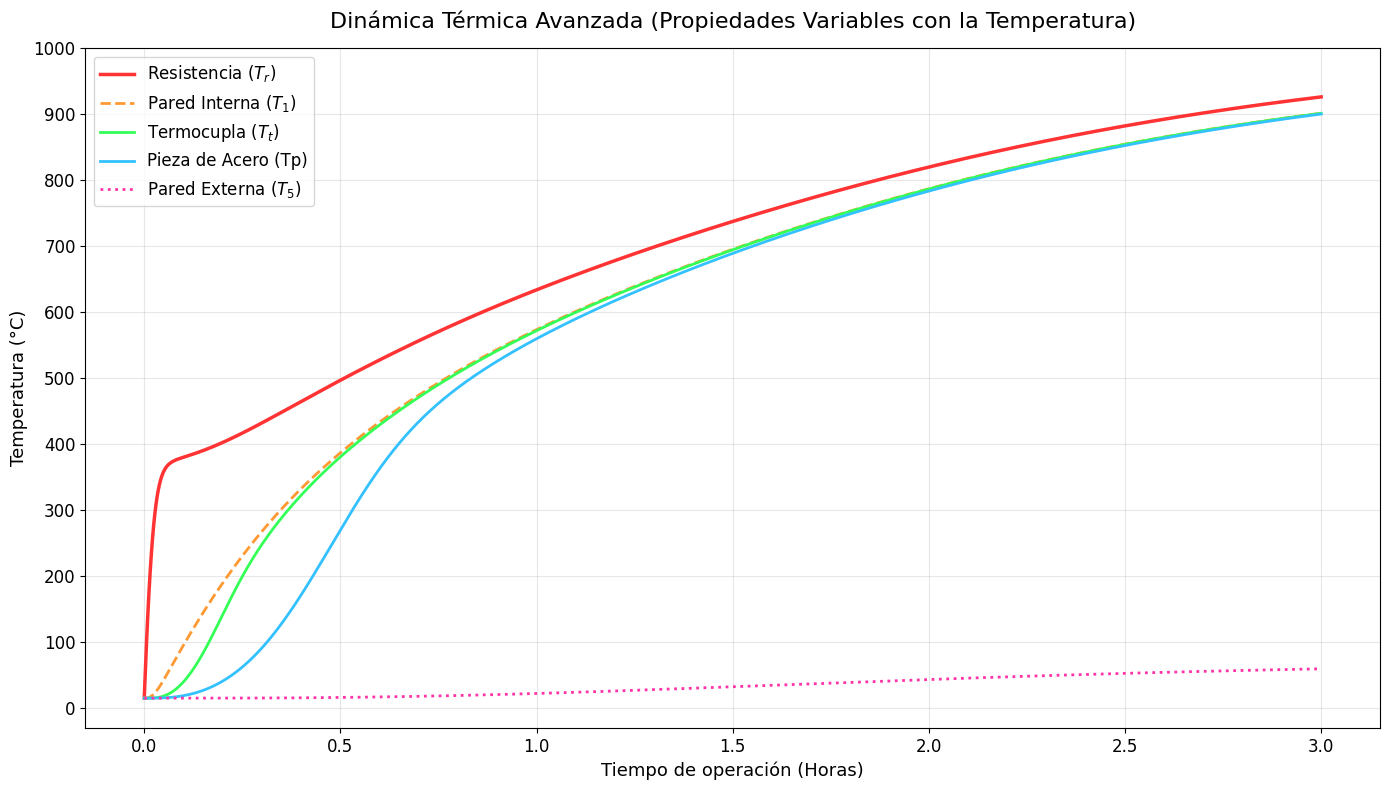

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. Definición de Propiedades Dependientes de T
# (Se asume que las fórmulas empíricas reciben T en °C)
# ==========================================
def c_r(T_C):
    # Calor específico de la resistencia
    return -0.0002 * (T_C**2) + 0.4804 * T_C + 467.6354

def k_lra(T_C):
    # Conductividad Ladrillo Refractario Aislante
    return -1e-8 * (T_C**2) + 0.0002 * T_C + 0.0990

def k_fc(T_C):
    # Conductividad Fibra Cerámica
    return 9e-7 * (T_C**2) + 0.0009 * T_C + 0.3033 #0.0002 * T_C + 0.0160

def k_lr(T_C):
    # Conductividad Ladrillo Refractario (o aislante secundario)
    return 2e-7 * T_C**2 + 0.0001 * T_C + 0.0301

# ==========================================
# 2. Parámetros y Condiciones Iniciales
# ==========================================
T_inf_C = 15.0              # Temperatura ambiente en °C
T_inf = T_inf_C + 273.15    # Temperatura ambiente en K
P_nominal = 600.0          # Potencia eléctrica P(t) en Watts
m_p = 0.120                # Masa de una probeta

# Condiciones iniciales: Todo a temperatura ambiente (en Kelvin)
if m_p != 0.0:
    y0 = [T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf]
else:
    y0 = [T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf]
# [0:Tr, 1:Tp, 2:Tt, 3:T1, 4:T2, 5:T3, 6:T4, 7:T5]

# Tiempo de simulación: 3 horas
t_span = (0, 3 * 3600)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

# ==========================================
# 3. Definición del Sistema de EDOs No Lineales
# ==========================================
def horno_mufla_avanzado_ode(t, y, P_val, T_amb, m_p):
    if m_p != 0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    # --- Conversión a °C para evaluar propiedades ---
    Tr_C = Tr - 273.15
    # Temperaturas promedio en las interfaces para las conductividades
    T12_C = ((T1 + T2) / 2.0) - 273.15
    T23_C = ((T2 + T3) / 2.0) - 273.15
    T34_C = ((T3 + T4) / 2.0) - 273.15
    T45_C = ((T4 + T5) / 2.0) - 273.15
    
    # Evaluamos propiedades dependientes del estado actual
    cr_val = c_r(Tr_C)
    klra_val_12 = k_lra(T12_C)
    kfc_val_23  = k_fc(T23_C)
    klr_val_34  = k_lr(T34_C)
    klr_val_45  = k_lr(T45_C)
    
    # --- Ecuaciones Diferenciales ---
    # Resistencia
    dTr_dt = (3.44 / cr_val) * P_val - (1.24e-8 / cr_val) * (Tr**4 - T1**4)
    
    # Pieza y Termocupla
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    
    # Nodos de la Pared (T1 a T5)
    if m_p != 0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
             
    dT2_dt = 0.0026 * klra_val_12 * (T1 - T2) - 0.0051 * kfc_val_23 * (T2 - T3)
    
    # Nota: Se usa kfc_val_23 asumiendo que k_cf del texto original era un error de tipeo por k_fc
    dT3_dt = 0.0113 * kfc_val_23 * (T2 - T3) - 0.0161 * klr_val_34 * (T3 - T4)
    
    dT4_dt = 0.0253 * klr_val_34 * (T3 - T4) - 0.0342 * klr_val_45 * (T4 - T5)
    
    dT5_dt = 0.0595 * klr_val_45 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)
    
    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]   

# ==========================================
# 4. Resolución Numérica
# ==========================================
print("Resolviendo sistema no lineal rígido (Stiff ODE). Por favor, espera...")

# 'Radau' sigue siendo obligatorio aquí, más aún con parámetros variables
sol = solve_ivp(
    fun=lambda t, y: horno_mufla_avanzado_ode(t, y, P_nominal, T_inf, m_p),
    t_span=t_span,
    y0=y0,
    method='Radau',
    t_eval=t_eval,
    rtol=1e-6, 
    atol=1e-9  
)

if sol.success:
    print("¡Integración exitosa!")
else:
    print("Error en la integración:", sol.message)

# Convertir todo a °C para graficar
t_horas = sol.t / 3600
Tr_C = sol.y[0] - 273.15
if m_p != 0.0:
    Tp_C = sol.y[1] - 273.15
    Tt_C = sol.y[2] - 273.15
    T1_C = sol.y[3] - 273.15
    T5_C = sol.y[7] - 273.15 # Pared externa
else:
    Tt_C = sol.y[1] - 273.15
    T1_C = sol.y[2] - 273.15
    T5_C = sol.y[6] - 273.15 # Pared externa

# ==========================================
# 5. Generación de Gráficas de Alta Calidad
# ==========================================
plt.figure(figsize=(14, 8))
plt.rcdefaults()
#plt.style.use('dark_background')

# Gráficas principales
plt.plot(t_horas, Tr_C, label='Resistencia ($T_r$)', color='#FF3333', linewidth=2.5)
plt.plot(t_horas, T1_C, label='Pared Interna ($T_1$)', color='#FF9933', linestyle='--', linewidth=2)
plt.plot(t_horas, Tt_C, label='Termocupla ($T_t$)', color='#33FF57', linewidth=2)
if m_p != 0:
    plt.plot(t_horas, Tp_C, label='Pieza de Acero (Tp)', color='#33C1FF', linewidth=2)

# Gráficas del perfil de la pared
plt.plot(t_horas, T5_C, label='Pared Externa ($T_5$)', color='#FF33A8', linestyle=':', linewidth=2)

plt.title('Dinámica Térmica Avanzada (Propiedades Variables con la Temperatura)', fontsize=16, pad=15)
plt.xlabel('Tiempo de operación (Horas)', fontsize=13)
plt.ylabel('Temperatura (°C)', fontsize=13)
plt.grid(True, alpha=0.3)

# Configuración explícita de ejes para asegurar visibilidad en cualquier IDE
plt.xticks(np.arange(0, 3.5, 0.5), fontsize=12)
plt.yticks(np.arange(0, 1050, 100), fontsize=12)
# plt.tick_params(axis='both', colors='white', labelsize=12)

# Leyenda profesional
plt.legend(loc='upper left', fontsize=12, framealpha=0.8)

plt.tight_layout()
plt.show()

## Diferencia entre modelos

Lo realizamos mediante un script que compara los resultados y halla la desviación entre ambos modelos:

Ejecutando Modelos...

--- Métricas para Pared Interna (T1) ---
Error Máximo: 70.30 °C
MAE (Error Medio): 28.39 °C
RMSE (Raíz de Error Cuadrático): 33.18 °C

--- Métricas para Termocupla (Tt) ---
Error Máximo: 70.21 °C
MAE (Error Medio): 28.40 °C
RMSE (Raíz de Error Cuadrático): 33.34 °C

--- Métricas para Pieza de Acero (Tp) ---
Error Máximo: 69.65 °C
MAE (Error Medio): 28.98 °C
RMSE (Raíz de Error Cuadrático): 34.87 °C

--- Métricas para Pared Externa (T5) ---
Error Máximo: 5.94 °C
MAE (Error Medio): 3.14 °C
RMSE (Raíz de Error Cuadrático): 3.69 °C


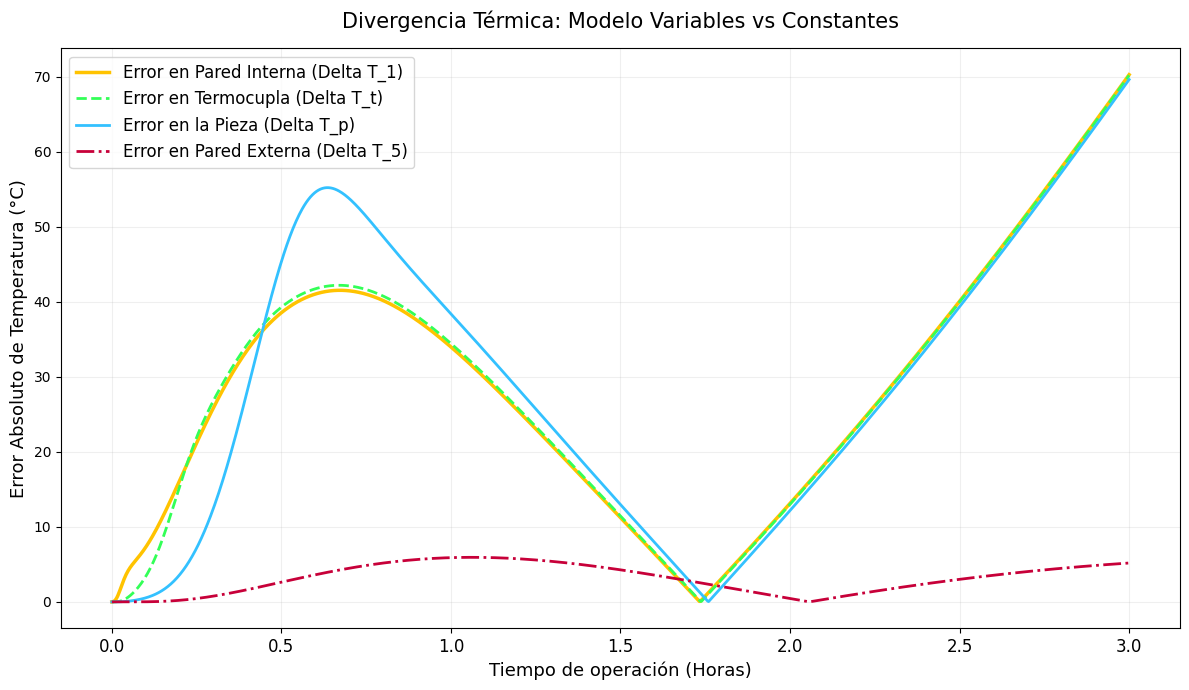

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ==========================================
# 1. Definición de Propiedades Variables
# ==========================================
def c_r(T_C): return -0.0002 * (T_C**2) + 0.4804 * T_C + 467.6354
def k_lra(T_C): return -1e-8 * (T_C**2) + 0.0002 * T_C + 0.0990
def k_fc(T_C): return 9e-7 * (T_C**2) + 0.0009 * T_C + 0.3033
def k_lr(T_C): return 2e-7 * (T_C**2) + 0.0001 * T_C + 0.0301

# ==========================================
# 2. Modelos Matemáticos (Funciones ODE)
# ==========================================
# Modelo 1: Propiedades Constantes
def horno_ode_constante(t, y, P_val, T_amb, m_p):
    if m_p != 0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    dTr_dt = 0.0054 * P_val - 1.94e-11 * (Tr**4 - T1**4)
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    if m_p != 0.0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 7.77e-4 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 7.77e-4 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
    dT2_dt = 5.22e-4 * (T1 - T2) - 9.63e-4 * (T2 - T3)
    dT3_dt = 0.0021 * (T2 - T3) - 0.0014 * (T3 - T4)
    dT4_dt = 0.0023 * (T3 - T4) - 0.0031 * (T4 - T5)
    dT5_dt = 0.0054 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)
    
    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt] 

# Modelo 2: Propiedades Variables
def horno_ode_variable(t, y, P_val, T_amb, m_p):
    if m_p != 0:
        Tr, Tp, Tt, T1, T2, T3, T4, T5 = y
    else:
        Tr, Tt, T1, T2, T3, T4, T5 = y
    
    Tr_C = Tr - 273.15
    T12_C = ((T1 + T2) / 2.0) - 273.15
    T23_C = ((T2 + T3) / 2.0) - 273.15
    T34_C = ((T3 + T4) / 2.0) - 273.15
    T45_C = ((T4 + T5) / 2.0) - 273.15
    
    cr_val = c_r(Tr_C)
    klra_val_12 = k_lra(T12_C)
    kfc_val_23  = k_fc(T23_C)
    klr_val_34  = k_lr(T34_C)
    klr_val_45  = k_lr(T45_C)
    
    dTr_dt = (3.44 / cr_val) * P_val - (1.24e-8 / cr_val) * (Tr**4 - T1**4)
    if m_p != 0.0:
        dTp_dt = (7.99e-13 + 6.57e-13 * np.sqrt(1/m_p)) * (T1**4 - Tp**4)
    dTt_dt = 2.0679e-11 * (T1**4 - Tt**4)
    if m_p != 0:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4) - 7.80e-14 * (T1**4 - Tp**4)
    else:
        dT1_dt = 1.95e-12 * (Tr**4 - T1**4) - 0.0039 * klra_val_12 * (T1 - T2) \
             - 6.85e-16 * (T1**4 - Tt**4)
    dT2_dt = 0.0026 * klra_val_12 * (T1 - T2) - 0.0051 * kfc_val_23 * (T2 - T3)
    dT3_dt = 0.0113 * kfc_val_23 * (T2 - T3) - 0.0161 * klr_val_34 * (T3 - T4)
    dT4_dt = 0.0253 * klr_val_34 * (T3 - T4) - 0.0342 * klr_val_45 * (T4 - T5)
    dT5_dt = 0.0595 * klr_val_45 * (T4 - T5) - 0.0202 * (T5 - T_amb) - 1.98e-11 * (T5**4 - T_amb**4)
    
    if m_p != 0.0:
        return [dTr_dt, dTp_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt]
    else:
        return [dTr_dt, dTt_dt, dT1_dt, dT2_dt, dT3_dt, dT4_dt, dT5_dt] 

# ==========================================
# 3. Configuración y Ejecución
# ==========================================
T_inf = 15.0 + 273.15
P_nominal = 600
m_p = 0.120

# Condiciones iniciales: Todo a temperatura ambiente (en Kelvin)
if m_p != 0.0:
    y0 = [T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf]
else:
    y0 = [T_inf, T_inf, T_inf, T_inf, T_inf, T_inf, T_inf]

t_span = (0, 3 * 3600)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

print("Ejecutando Modelos...")
sol_const = solve_ivp(lambda t, y: horno_ode_constante(t, y, P_nominal, T_inf, m_p), 
                      t_span, y0, method='Radau', t_eval=t_eval, rtol=1e-6, atol=1e-9)

sol_var = solve_ivp(lambda t, y: horno_ode_variable(t, y, P_nominal, T_inf, m_p), 
                    t_span, y0, method='Radau', t_eval=t_eval, rtol=1e-6, atol=1e-9)

# ==========================================
# 4. Extracción de Nodos Específicos y Cálculo de Errores
# ==========================================
# Pieza (Tp), Termocupla (Tt), Pared Interna (T1), Pared Externa (T5)
if m_p != 0:
    Tp_const, Tp_var = sol_const.y[1] - 273.15, sol_var.y[1] - 273.15
    Tt_const, Tt_var = sol_const.y[2] - 273.15, sol_var.y[2] - 273.15
    T1_const, T1_var = sol_const.y[3] - 273.15, sol_var.y[3] - 273.15
    T5_const, T5_var = sol_const.y[7] - 273.15, sol_var.y[7] - 273.15
else:
    Tt_const, Tt_var = sol_const.y[1] - 273.15, sol_var.y[1] - 273.15
    T1_const, T1_var = sol_const.y[2] - 273.15, sol_var.y[2] - 273.15
    T5_const, T5_var = sol_const.y[6] - 273.15, sol_var.y[6] - 273.15 

# Diferencia absoluta entre modelos
if m_p != 0:
    err_Tp = np.abs(Tp_var - Tp_const)
err_Tt = np.abs(Tt_var - Tt_const)
err_T1 = np.abs(T1_var - T1_const)
err_T5 = np.abs(T5_var - T5_const)

def print_metrics(name, error_array):
    mae = np.mean(error_array)
    rmse = np.sqrt(np.mean(error_array**2))
    max_err = np.max(error_array)
    print(f"\n--- Métricas para {name} ---")
    print(f"Error Máximo: {max_err:.2f} °C")
    print(f"MAE (Error Medio): {mae:.2f} °C")
    print(f"RMSE (Raíz de Error Cuadrático): {rmse:.2f} °C")

print_metrics("Pared Interna (T1)", err_T1)
print_metrics("Termocupla (Tt)", err_Tt)
if m_p != 0:
    print_metrics("Pieza de Acero (Tp)", err_Tp)
print_metrics("Pared Externa (T5)", err_T5)

# ==========================================
# 5. Visualización Exclusiva del Error
# ==========================================
t_horas = sol_const.t / 3600

plt.figure(figsize=(12, 7))
plt.rcdefaults()
# plt.style.use('dark_background')

# Trazamos solo los 4 nodos solicitados
plt.plot(t_horas, err_T1, label='Error en Pared Interna (Delta T_1)', color='#FFC300', linewidth=2.5)
plt.plot(t_horas, err_Tt, label='Error en Termocupla (Delta T_t)', color='#33FF57', linestyle='--', linewidth=2)
if m_p != 0:
    plt.plot(t_horas, err_Tp, label='Error en la Pieza (Delta T_p)', color='#33C1FF', linewidth=2)
plt.plot(t_horas, err_T5, label='Error en Pared Externa (Delta T_5)', color='#C70039', linestyle='-.', linewidth=2)

plt.title('Divergencia Térmica: Modelo Variables vs Constantes', fontsize=15, pad=15)
plt.xlabel('Tiempo de operación (Horas)', fontsize=13)
plt.ylabel('Error Absoluto de Temperatura (°C)', fontsize=13)

plt.xticks(np.arange(0, 3.5, 0.5), fontsize=12)
plt.grid(True, alpha=0.2)
plt.legend(loc='upper left', fontsize=12, framealpha=0.8)

plt.tight_layout()
plt.show()